# Retail Demand Variability and Inventory Inefficiency Analysis
### Supply Chain Analytics — Intern Assessment

**Dataset:** Store Item Demand Forecasting — 10 stores x 50 items x 5 years (2013–2017)  
**Source:** Kaggle Store Item Demand Forecasting Competition (US-origin dataset)  
**SKU definition:** `store_item` composite key — 500 unique SKUs  
**Category definition:** Items 1–10 = Cat_A, 11–20 = Cat_B, 21–30 = Cat_C, 31–40 = Cat_D, 41–50 = Cat_E  

---

**Notebook Structure**

| Section | Content |
|---------|---------|
| 0 | Setup — libraries, constants, paths |
| 1 | Data loading and validation |
| 2 | Feature engineering — date, weekend, holiday (US federal), category flags |
| 3 | Demand volatility — CV per SKU, tier classification |
| 4 | Inventory simulation — deterministic replenishment model |
| 5 | Stockout and overstock — occurrence rate, duration distribution, financial impact |
| 6 | Pareto analysis — SKUs driving 80% of financial impact |
| 7 | Holiday demand lift — Wilcoxon signed-rank per category (US federal holidays) |
| 8 | Weekday vs weekend — Mann-Whitney U and Cohen's d per category |
| 9 | Structural waste analysis — wastage proxy, ranking, structural annotation |
| 10 | Statistical validation — Spearman, Kruskal-Wallis, safety stock comparison |
| 11 | Annotated visualisations — 7 charts |
| 12 | Deliverable summary tables |
| 13 | Key findings and replenishment recommendations |

---
## Section 0 — Setup and Assumptions

### Financial Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Unit price | Rs.100 | Normalised proxy; scales all cost estimates uniformly |
| Annual carrying cost | 25% | Standard FMCG benchmark (storage, capital, spoilage risk) |
| Daily carrying cost | 0.0685% | Annual / 365 |

### Inventory Policy Parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Replenishment cycle | 7 days | Weekly restocking, standard for store-level retail |
| Safety stock Z-score | 1.65 | 95th percentile service level target |
| Lead time | 7 days | One replenishment cycle — dataset constraint, no variation available |
| Stockout threshold | stock < 1.5x weekly avg | Demand-at-risk zone within replenishment horizon |
| Overstock threshold | stock > 2.0x weekly avg | Capital-trapped zone, double-EOQ heuristic |

All constants are defined once here and referenced throughout. Changing a value recalibrates all downstream figures automatically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, wilcoxon, kruskal, spearmanr
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RAW_DATA_PATH = "../data/raw/train.csv"
FIGURES_PATH  = "outputs/figures/"
TABLES_PATH   = "outputs/tables/"
for p in [FIGURES_PATH, TABLES_PATH]:
    os.makedirs(p, exist_ok=True)

UNIT_PRICE           = 100
CARRYING_COST_ANNUAL = 0.25
CARRYING_COST_DAILY  = CARRYING_COST_ANNUAL / 365

REPLENISHMENT_CYCLE      = 7
Z_SCORE                  = 1.65
LEAD_TIME                = 7
STOCKOUT_THRESHOLD_MULT  = 1.5
OVERSTOCK_THRESHOLD_MULT = 2.0

print("Configuration loaded.")
print(f"  Unit Price       : Rs.{UNIT_PRICE}")
print(f"  Carrying Cost    : {CARRYING_COST_ANNUAL*100:.0f}% p.a.  ({CARRYING_COST_DAILY*100:.4f}% per day)")
print(f"  Replenishment    : every {REPLENISHMENT_CYCLE} days")
print(f"  Safety stock Z   : {Z_SCORE}  (service level ~95%)")
print(f"  Stockout trigger : stock < {STOCKOUT_THRESHOLD_MULT}x weekly avg")
print(f"  Overstock trigger: stock > {OVERSTOCK_THRESHOLD_MULT}x weekly avg")

Configuration loaded.
  Unit Price       : Rs.100
  Carrying Cost    : 25% p.a.  (0.0685% per day)
  Replenishment    : every 7 days
  Safety stock Z   : 1.65  (service level ~95%)
  Stockout trigger : stock < 1.5x weekly avg
  Overstock trigger: stock > 2.0x weekly avg


---
## Section 1 — Data Loading and Validation

**Dataset origin:** This is the Kaggle Store Item Demand Forecasting dataset — a US retail dataset. Accordingly, all holiday analysis in Section 7 uses US federal holidays, not Indian ones.

Checks performed: shape integrity, date continuity, null values, duplicate records, negative sales.

In [2]:
df = pd.read_csv(RAW_DATA_PATH, parse_dates=['date'])

print(f"Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range     : {df['date'].min().date()}  to  {df['date'].max().date()}")
print(f"Null values    : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated(subset=['date','store','item']).sum()}")
print(f"Negative sales : {(df['sales'] < 0).sum()}")
print(f"Unique stores  : {df['store'].nunique()}  |  Items : {df['item'].nunique()}")

df['sku'] = df['store'].astype(str) + '_' + df['item'].astype(str)
df = df.sort_values(['sku', 'date']).reset_index(drop=True)

print(f"Total SKUs     : {df['sku'].nunique()}  (10 stores x 50 items)")

expected_days = (df['date'].max() - df['date'].min()).days + 1
coverage = df.groupby('sku')['date'].count()
print(f"Expected days per SKU : {expected_days} | Min observed : {coverage.min()} | Max : {coverage.max()}")
if coverage.min() == expected_days:
    print("Dataset is complete — no date gaps in any SKU time series.")
else:
    print("WARNING: Some SKUs have missing dates.")

print("\nSales distribution:")
print(df['sales'].describe().round(2).to_string())

Shape          : 913,000 rows x 4 columns
Date range     : 2013-01-01  to  2017-12-31
Null values    : 0
Duplicate rows : 0
Negative sales : 0
Unique stores  : 10  |  Items : 50
Total SKUs     : 500  (10 stores x 50 items)
Expected days per SKU : 1826 | Min observed : 1826 | Max : 1826
Dataset is complete — no date gaps in any SKU time series.

Sales distribution:
count    913000.00
mean         52.25
std          28.80
min           0.00
25%          30.00
50%          47.00
75%          70.00
max         231.00


---
## Section 2 — Feature Engineering

**Category definition:** The dataset has no explicit category column. Items are grouped into 5 equal-sized categories of 10 items each (Cat_A: items 1–10 through Cat_E: items 41–50). This is the analytical unit for all category-level statistical tests, consistent with how retail product hierarchies are structured.

**Holiday flag — US Federal Holidays:**  
This dataset is US-origin (Kaggle Store Item Demand Forecasting). All holiday analysis therefore uses US federal holidays for 2013–2017, computed from statutory rules (observed date rules applied where a holiday falls on a weekend). The `holidays` Python package would be the production-grade source; here the dates are defined inline from the federal calendar.

The 10 US federal holidays are: New Year's Day, MLK Day, Presidents Day, Memorial Day, Independence Day, Labor Day, Columbus Day, Veterans Day, Thanksgiving, Christmas.

**Weekend flag:** Saturday (dayofweek=5) and Sunday (dayofweek=6).

In [3]:
# Date decomposition
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['dayofweek']  = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['quarter']    = df['date'].dt.quarter
df['year_week']  = df['date'].dt.to_period('W')

# Category assignment
def assign_category(item):
    if item <= 10:   return 'Cat_A'
    elif item <= 20: return 'Cat_B'
    elif item <= 30: return 'Cat_C'
    elif item <= 40: return 'Cat_D'
    else:            return 'Cat_E'

df['category'] = df['item'].apply(assign_category)

# US Federal Holidays 2013-2017
# Dates computed from federal statute (observed rules applied when holiday falls on weekend)
# Production note: replace with holidays.US(years=range(2013,2018)) when network is available
US_HOLIDAYS = {
    '2013-01-01': "New Year's Day",        '2013-01-21': "MLK Day",
    '2013-02-18': "Presidents Day",        '2013-05-27': "Memorial Day",
    '2013-07-04': "Independence Day",      '2013-09-02': "Labor Day",
    '2013-10-14': "Columbus Day",          '2013-11-11': "Veterans Day",
    '2013-11-28': "Thanksgiving",          '2013-12-25': "Christmas",

    '2014-01-01': "New Year's Day",        '2014-01-20': "MLK Day",
    '2014-02-17': "Presidents Day",        '2014-05-26': "Memorial Day",
    '2014-07-04': "Independence Day",      '2014-09-01': "Labor Day",
    '2014-10-13': "Columbus Day",          '2014-11-11': "Veterans Day",
    '2014-11-27': "Thanksgiving",          '2014-12-25': "Christmas",

    '2015-01-01': "New Year's Day",        '2015-01-19': "MLK Day",
    '2015-02-16': "Presidents Day",        '2015-05-25': "Memorial Day",
    '2015-07-03': "Independence Day (obs)",'2015-09-07': "Labor Day",
    '2015-10-12': "Columbus Day",          '2015-11-11': "Veterans Day",
    '2015-11-26': "Thanksgiving",          '2015-12-25': "Christmas",

    '2016-01-01': "New Year's Day",        '2016-01-18': "MLK Day",
    '2016-02-15': "Presidents Day",        '2016-05-30': "Memorial Day",
    '2016-07-04': "Independence Day",      '2016-09-05': "Labor Day",
    '2016-10-10': "Columbus Day",          '2016-11-11': "Veterans Day",
    '2016-11-24': "Thanksgiving",          '2016-12-26': "Christmas (obs)",

    '2017-01-02': "New Year's Day (obs)",  '2017-01-16': "MLK Day",
    '2017-02-20': "Presidents Day",        '2017-05-29': "Memorial Day",
    '2017-07-04': "Independence Day",      '2017-09-04': "Labor Day",
    '2017-10-09': "Columbus Day",          '2017-11-10': "Veterans Day (obs)",
    '2017-11-23': "Thanksgiving",          '2017-12-25': "Christmas",
}

_holiday_ts_map = {pd.Timestamp(k): v for k, v in US_HOLIDAYS.items()}
_holiday_dates  = pd.DatetimeIndex(_holiday_ts_map.keys())
df['is_holiday']   = df['date'].isin(_holiday_dates).astype(int)
df['holiday_name'] = df['date'].map(_holiday_ts_map).fillna('')

# Weekly demand aggregation
weekly_sku = (
    df.groupby(['sku','store','item','category','year_week'])['sales']
    .sum().reset_index().rename(columns={'sales': 'weekly_demand'})
)

print("Category mapping:")
for cat in sorted(df['category'].unique()):
    items = sorted(df[df['category']==cat]['item'].unique())
    print(f"  {cat}: items {items[0]}-{items[-1]}  ({len(items)} items x 10 stores = {len(items)*10} SKUs)")

print(f"\nUS federal holidays flagged   : {df['is_holiday'].sum():,} rows  ({df[df['is_holiday']==1]['date'].nunique()} unique dates)")
print(f"Weekend rows                  : {df['is_weekend'].sum():,}  ({df['is_weekend'].mean()*100:.1f}% of records)")

print(f"\nMean daily sales — holiday days   : {df[df['is_holiday']==1]['sales'].mean():.2f}")
print(f"Mean daily sales — non-holidays   : {df[df['is_holiday']==0]['sales'].mean():.2f}")
print(f"Mean daily sales — weekends       : {df[df['is_weekend']==1]['sales'].mean():.2f}")
print(f"Mean daily sales — weekdays       : {df[df['is_weekend']==0]['sales'].mean():.2f}")

print("\nMean demand by holiday type:")
hol_demand = df[df['is_holiday']==1].groupby('holiday_name')['sales'].mean().sort_values(ascending=False)
for name, val in hol_demand.items():
    marker = "  [above baseline]" if val > df[df['is_holiday']==0]['sales'].mean() else "  [below baseline]"
    print(f"  {name:<30} {val:.1f}{marker}")

Category mapping:
  Cat_A: items 1-10  (10 items x 10 stores = 100 SKUs)
  Cat_B: items 11-20  (10 items x 10 stores = 100 SKUs)
  Cat_C: items 21-30  (10 items x 10 stores = 100 SKUs)
  Cat_D: items 31-40  (10 items x 10 stores = 100 SKUs)
  Cat_E: items 41-50  (10 items x 10 stores = 100 SKUs)

US federal holidays flagged   : 25,000 rows  (50 unique dates)
Weekend rows                  : 261,000  (28.6% of records)

Mean daily sales — holiday days   : 43.09
Mean daily sales — non-holidays   : 52.51
Mean daily sales — weekends       : 60.40
Mean daily sales — weekdays       : 48.99

Mean demand by holiday type:
  Independence Day (obs)         71.0  [above baseline]
  Veterans Day (obs)             65.7  [above baseline]
  Independence Day               62.6  [above baseline]
  Thanksgiving                   54.7  [above baseline]
  Veterans Day                   50.1  [below baseline]
  Memorial Day                   46.6  [below baseline]
  Labor Day                      43.8  [belo

---
## Section 3 — Demand Volatility: Coefficient of Variation

CV = sigma / mu computed on daily sales per SKU — the standard normalised measure of demand uncertainty, enabling comparison across SKUs with different mean demand levels.

**Tier classification:**

| Tier | CV Range | Inventory Implication |
|------|----------|----------------------|
| Low | CV < 0.20 | Fixed-cycle ordering may suffice |
| Medium | 0.20 to 0.49 | Safety stock required |
| High | CV >= 0.50 | Demand-driven reorder points required |

**Dataset observation:** All 500 SKUs fall in the Medium tier (CV range: 0.26–0.37). This is structurally expected for aggregate store-level daily demand across a 5-year horizon. The implication is that (a) safety stock is universally required — no SKU qualifies for a simple fixed-order policy — and (b) since no SKU reaches the High tier, stockout is not the dominant cost driver. Overstock and its associated carrying cost waste will dominate.

In [4]:
sku_cv = (
    df.groupby(['sku','category','item','store'])['sales']
    .agg(mean_demand='mean', std_demand='std', total_demand='sum', obs_count='count')
    .reset_index()
)
sku_cv['cv'] = np.where(
    sku_cv['mean_demand'] == 0, 0.0,
    sku_cv['std_demand'] / sku_cv['mean_demand']
).astype(float)

conditions = [sku_cv['cv'] < 0.20, sku_cv['cv'] < 0.50]
sku_cv['volatility_tier'] = np.select(conditions, ['Low', 'Medium'], default='High')

sku_weekly_stats = (
    weekly_sku.groupby('sku')['weekly_demand']
    .agg(weekly_mean='mean', weekly_std='std').reset_index()
)
sku_weekly_stats['weekly_std'] = sku_weekly_stats['weekly_std'].fillna(0)
sku_cv = sku_cv.merge(sku_weekly_stats, on='sku', how='left')

print("Volatility Tier Distribution:")
print(sku_cv['volatility_tier'].value_counts().to_string())
print(f"\nCV range : {sku_cv['cv'].min():.4f} to {sku_cv['cv'].max():.4f}")
print(f"Mean CV  : {sku_cv['cv'].mean():.4f}  |  Median : {sku_cv['cv'].median():.4f}")
print(f"\nCV by category:")
print(sku_cv.groupby('category')['cv'].agg(['mean','min','max']).round(4).to_string())
print(f"\nWeekly mean demand range : {sku_cv['weekly_mean'].min():.1f} to {sku_cv['weekly_mean'].max():.1f} units")

Volatility Tier Distribution:
volatility_tier
Medium    500

CV range : 0.2616 to 0.3734
Mean CV  : 0.2905  |  Median : 0.2839

CV by category:
            mean     min     max
category                        
Cat_A     0.2963  0.2649  0.3734
Cat_B     0.2832  0.2616  0.3448
Cat_C     0.2872  0.2618  0.3601
Cat_D     0.2891  0.2623  0.3430
Cat_E     0.2969  0.2647  0.3554

Weekly mean demand range : 89.1 to 788.0 units


---
## Section 4 — Inventory Simulation

The dataset contains only sales — no stock-on-hand column. A deterministic replenishment model reconstructs stock trajectories under a defined policy, enabling measurement of stockout and overstock against a rule the business controls.

**Model:** `stock_t = stock_(t-1) + replenishment_t - demand_t`

- Initial stock = 2x average weekly demand
- Replenishment = 1x weekly average every 7 days
- Fulfilled demand = min(stock, demand) — no backorders
- Safety stock (formula) = Z x sigma_weekly x sqrt(lead_time / 7)

**Lead time constraint:** Lead time is held constant at 7 days — no variation data exists in this dataset. The structural waste analysis in Section 9 therefore uses CV and turnover ratio as proxies for demand complexity rather than lead time CV.

In [5]:
def simulate_inventory(demand_series, weekly_avg):
    """Deterministic weekly replenishment simulation. Returns daily stock and fulfilled demand."""
    stock = 2 * weekly_avg
    stock_levels, fulfilled = [], []
    for day_idx, demand in enumerate(demand_series):
        if day_idx % REPLENISHMENT_CYCLE == 0 and day_idx != 0:
            stock += weekly_avg
        fulfilled_demand = min(stock, demand)
        stock = max(stock - demand, 0)
        stock_levels.append(stock)
        fulfilled.append(fulfilled_demand)
    return stock_levels, fulfilled


weekly_avg_dict = dict(zip(sku_weekly_stats['sku'], sku_weekly_stats['weekly_mean']))

print("Running simulation across 500 SKUs...")
results = []
for sku_id, group in df.groupby('sku'):
    group = group.sort_values('date').reset_index(drop=True)
    weekly_avg = weekly_avg_dict.get(sku_id, group['sales'].mean() * 7)
    stock_levels, fulfilled = simulate_inventory(group['sales'].values, weekly_avg)
    temp = group[['date','sku','store','item','category','sales','is_holiday','is_weekend','holiday_name']].copy()
    temp['stock']            = stock_levels
    temp['fulfilled_demand'] = fulfilled
    temp['weekly_avg']       = weekly_avg
    results.append(temp)

sim_df = pd.concat(results, ignore_index=True)

sim_df['lost_sales']      = sim_df['sales'] - sim_df['fulfilled_demand']
sim_df['stockout_flag']   = (sim_df['stock'] < STOCKOUT_THRESHOLD_MULT * sim_df['weekly_avg']).astype(int)
sim_df['overstock_flag']  = (sim_df['stock'] > OVERSTOCK_THRESHOLD_MULT * sim_df['weekly_avg']).astype(int)
sim_df['actual_stockout'] = (sim_df['lost_sales'] > 0).astype(int)

sim_df = sim_df.merge(sku_cv[['sku','weekly_std','weekly_mean','cv','volatility_tier']], on='sku', how='left')
sim_df['safety_stock_formula'] = Z_SCORE * sim_df['weekly_std'] * np.sqrt(LEAD_TIME / 7)
sim_df['stockout_safety']      = (sim_df['stock'] < sim_df['safety_stock_formula']).astype(int)

print(f"Simulation complete. Rows: {sim_df.shape[0]:,}")
print(f"\nStockout risk days  (stock < 1.5x avg) : {sim_df['stockout_flag'].mean()*100:.1f}%")
print(f"Overstock days      (stock > 2.0x avg) : {sim_df['overstock_flag'].mean()*100:.1f}%")
print(f"Actual lost-sale days                  : {sim_df['actual_stockout'].mean()*100:.4f}%")

Running simulation across 500 SKUs...
Simulation complete. Rows: 913,000

Stockout risk days  (stock < 1.5x avg) : 3.7%
Overstock days      (stock > 2.0x avg) : 94.4%
Actual lost-sale days                  : 0.0018%


---
## Section 5 — Stockout and Overstock: Occurrence Rate, Duration Distribution, Financial Impact

**Programmatic definitions:**
- Stockout risk: `stock < 1.5 x avg weekly demand` (heuristic threshold)
- Stockout formula: `stock < Z x sigma_weekly x sqrt(lead_time/7)` (formula-based safety stock breach)
- Overstock: `stock > 2.0 x avg weekly demand`

**Financial proxies:**
- Stockout cost: `lost_sales x unit_price`
- Overstock cost: `excess_units x daily_carrying_rate x unit_price`

**Duration distribution:** Both risks are quantified not just as occurrence rates but as distributions of consecutive episode lengths. This distinguishes episodic risk (short spikes, correctable by timing) from chronic risk (multi-week runs, requiring policy changes).

In [6]:
def get_consecutive_runs(flag_series):
    """Return list of all consecutive episode lengths (runs of 1s) in a binary series."""
    runs, cur = [], 0
    for v in flag_series:
        if v == 1:
            cur += 1
        else:
            if cur > 0:
                runs.append(cur)
                cur = 0
    if cur > 0:
        runs.append(cur)
    return runs


# Fill rate and stockout rate per SKU
sku_fill = (
    sim_df.groupby('sku')
    .agg(
        total_demand     = ('sales',           'sum'),
        total_fulfilled  = ('fulfilled_demand', 'sum'),
        stockout_days    = ('actual_stockout',  'sum'),
        total_days       = ('actual_stockout',  'count')
    )
    .reset_index()
)
sku_fill['fill_rate']     = (sku_fill['total_fulfilled'] / sku_fill['total_demand'].replace(0, np.nan)).fillna(1)
sku_fill['stockout_rate'] = sku_fill['stockout_days'] / sku_fill['total_days']
sku_fill['lost_units']    = sku_fill['total_demand'] - sku_fill['total_fulfilled']
sku_fill['lost_revenue']  = sku_fill['lost_units'] * UNIT_PRICE
sku_fill = sku_fill.merge(sku_cv[['sku','cv','volatility_tier','category']], on='sku', how='left')

# Financial impact
sim_df['stockout_cost']        = sim_df['lost_sales'] * UNIT_PRICE
sim_df['excess_units']         = np.maximum(sim_df['stock'] - (OVERSTOCK_THRESHOLD_MULT * sim_df['weekly_avg']), 0)
sim_df['overstock_cost']       = sim_df['excess_units'] * CARRYING_COST_DAILY * UNIT_PRICE
sim_df['net_financial_impact'] = sim_df['stockout_cost'] + sim_df['overstock_cost']

print("=== Fill Rate and Revenue Loss ===")
print(f"Mean fill rate       : {sku_fill['fill_rate'].mean():.6f}")
print(f"Total lost revenue   : Rs.{sku_fill['lost_revenue'].sum():,.0f}")

print("\n=== Financial Impact Summary ===")
print(f"Total Stockout Cost  : Rs.{sim_df['stockout_cost'].sum():>18,.0f}")
print(f"Total Overstock Cost : Rs.{sim_df['overstock_cost'].sum():>18,.0f}")
print(f"Net Financial Impact : Rs.{sim_df['net_financial_impact'].sum():>18,.0f}")
print(f"Overstock share      : {sim_df['overstock_cost'].sum()/sim_df['net_financial_impact'].sum()*100:.1f}%  (dominant waste driver)")

# Stockout duration distribution
print("\n=== Stockout Episode Duration Distribution ===")
stockout_runs_per_sku = {}
all_stockout_runs = []
for sku_id, grp in sim_df.groupby('sku'):
    runs = get_consecutive_runs(grp.sort_values('date')['stockout_flag'].values)
    stockout_runs_per_sku[sku_id] = {'max_consec': max(runs) if runs else 0, 'episode_count': len(runs)}
    all_stockout_runs.extend(runs)

so_series = pd.Series(all_stockout_runs)
print(f"Total stockout episodes (all SKUs) : {len(so_series):,}")
print(f"{'Percentile':<14} {'Days'}")
print("-" * 24)
for pct in [25, 50, 75, 90, 95, 99]:
    print(f"  {pct}th pct      : {so_series.quantile(pct/100):.0f} days")
print(f"  Max          : {so_series.max():.0f} days  |  Mean : {so_series.mean():.1f} days")

# Overstock duration distribution
print("\n=== Overstock Episode Duration Distribution ===")
overstock_runs_per_sku = {}
all_overstock_runs = []
for sku_id, grp in sim_df.groupby('sku'):
    runs = get_consecutive_runs(grp.sort_values('date')['overstock_flag'].values)
    overstock_runs_per_sku[sku_id] = {'max_consec': max(runs) if runs else 0, 'episode_count': len(runs)}
    all_overstock_runs.extend(runs)

ov_series = pd.Series(all_overstock_runs)
print(f"Total overstock episodes (all SKUs) : {len(ov_series):,}")
print(f"{'Percentile':<14} {'Days'}")
print("-" * 24)
for pct in [25, 50, 75, 90, 95, 99]:
    print(f"  {pct}th pct      : {ov_series.quantile(pct/100):.0f} days")
print(f"  Max          : {ov_series.max():.0f} days  |  Mean : {ov_series.mean():.1f} days")

# Per-SKU duration tables
stockout_duration = pd.DataFrame([
    {'sku': k, 'max_consecutive_stockout_days': v['max_consec'], 'stockout_episodes': v['episode_count']}
    for k, v in stockout_runs_per_sku.items()
])
overstock_duration = pd.DataFrame([
    {'sku': k, 'max_consecutive_overstock_days': v['max_consec'], 'overstock_episodes': v['episode_count']}
    for k, v in overstock_runs_per_sku.items()
])

# Financial impact per SKU
sku_financial = (
    sim_df.groupby(['sku','category'])
    .agg(
        total_stockout_cost  = ('stockout_cost',       'sum'),
        total_overstock_cost = ('overstock_cost',       'sum'),
        total_excess_units   = ('excess_units',         'sum'),
        net_impact           = ('net_financial_impact', 'sum'),
        avg_stock            = ('stock',                'mean'),
        total_demand         = ('sales',                'sum')
    )
    .reset_index()
)
sku_financial = sku_financial.merge(sku_cv[['sku','cv','volatility_tier']], on='sku', how='left')
sku_financial = sku_financial.sort_values('net_impact', ascending=False).reset_index(drop=True)

total_impact = sku_financial['net_impact'].sum()
sku_financial['impact_pct']     = sku_financial['net_impact'] / total_impact
sku_financial['cum_impact_pct'] = sku_financial['impact_pct'].cumsum()

print("\n=== Financial Impact by Category ===")
cat_financial = (
    sku_financial.groupby('category')
    .agg(total_overstock_cost=('total_overstock_cost','sum'), net_impact=('net_impact','sum'))
    .reset_index().sort_values('net_impact', ascending=False)
)
print(cat_financial.round(0).to_string(index=False))

=== Fill Rate and Revenue Loss ===
Mean fill rate       : 0.999995
Total lost revenue   : Rs.11,584

=== Financial Impact Summary ===
Total Stockout Cost  : Rs.            11,584
Total Overstock Cost : Rs.       172,252,412
Net Financial Impact : Rs.       172,263,996
Overstock share      : 100.0%  (dominant waste driver)

=== Stockout Episode Duration Distribution ===
Total stockout episodes (all SKUs) : 4,744
Percentile     Days
------------------------
  25th pct      : 2 days
  50th pct      : 3 days
  75th pct      : 5 days
  90th pct      : 27 days
  95th pct      : 41 days
  99th pct      : 54 days
  Max          : 83 days  |  Mean : 7.2 days

=== Overstock Episode Duration Distribution ===
Total overstock episodes (all SKUs) : 3,882
Percentile     Days
------------------------
  25th pct      : 2 days
  50th pct      : 4 days
  75th pct      : 5 days
  90th pct      : 1693 days
  95th pct      : 1706 days
  99th pct      : 1714 days
  Max          : 1749 days  |  Mean : 222.0 d

---
## Section 6 — Pareto Analysis

Rank all 500 SKUs by total financial impact and identify the minimum set driving 80% of the total burden. These are the priority intervention targets — blanket policy changes across all 500 SKUs dilute effort; targeted reviews on this set yield proportionally higher returns.

In [7]:
pareto_df = sku_financial[['sku','category','net_impact','volatility_tier']].copy()
pareto_df = pareto_df.sort_values('net_impact', ascending=False).reset_index(drop=True)

total_pareto = pareto_df['net_impact'].sum() or 1
pareto_df['cumulative_impact'] = pareto_df['net_impact'].cumsum()
pareto_df['cumulative_pct']    = 100 * pareto_df['cumulative_impact'] / total_pareto
pareto_df['sku_pct']           = 100 * (pareto_df.index + 1) / len(pareto_df)
pareto_df['impact_share']      = pareto_df['net_impact'] / total_pareto

cutoff_idx = pareto_df[pareto_df['cumulative_pct'] > 80].index.min()
pareto_df['is_top_contributor'] = (
    (pareto_df['cumulative_pct'] <= 80) | (pareto_df.index == cutoff_idx)
).astype(int)

top_skus = pareto_df[pareto_df['is_top_contributor'] == 1]
print("=== Pareto Analysis ===")
print(f"SKUs driving 80% of financial impact : {len(top_skus)} / {len(pareto_df)}  ({100*len(top_skus)/len(pareto_df):.1f}%)")
print(f"Cumulative impact at cutoff          : Rs.{top_skus['net_impact'].sum():,.0f}")
print(f"\nCategory breakdown within top contributors:")
print(top_skus.groupby('category')['sku'].count().rename('sku_count').to_string())
print(f"\nTop 10 SKUs by financial impact:")
print(pareto_df[['sku','category','net_impact','cumulative_pct']].head(10).to_string(index=False))

pareto_df.to_csv(TABLES_PATH + "pareto_analysis.csv", index=False)
print("\nSaved: pareto_analysis.csv")

=== Pareto Analysis ===
SKUs driving 80% of financial impact : 313 / 500  (62.6%)
Cumulative impact at cutoff          : Rs.138,046,522

Category breakdown within top contributors:
category
Cat_A    60
Cat_B    73
Cat_C    69
Cat_D    63
Cat_E    48

Top 10 SKUs by financial impact:
 sku category    net_impact  cumulative_pct
2_28    Cat_C 723599.752008        0.420053
2_15    Cat_B 721177.647615        0.838700
2_18    Cat_B 718248.984674        1.255646
8_15    Cat_B 709859.163911        1.667723
8_28    Cat_C 704579.956175        2.076734
2_13    Cat_B 699362.631082        2.482717
2_45    Cat_E 690230.065869        2.883399
8_18    Cat_B 686781.209258        3.282078
3_15    Cat_B 685861.847216        3.680224
2_25    Cat_C 684775.172414        4.077739

Saved: pareto_analysis.csv


---
## Section 7 — Holiday Demand Lift: Wilcoxon Signed-Rank Test per Category

**Geography:** This is a US dataset. All tests use US federal holidays (50 holiday-days across 2013–2017).

**Method:** For each category, aggregate mean daily sales to weekly level, flag weeks containing a federal holiday, and apply the Wilcoxon signed-rank test comparing holiday-week demand against non-holiday-week demand.

**Why weekly aggregation:** Using daily granularity would compare the holiday day itself against ordinary days — this is too noisy. Weekly aggregation captures the full demand effect including anticipatory buying and post-holiday slowdown.

**Interpretation:**
- Lift > 1.0 and p < 0.05: Holiday demand surge — pre-stocking recommended
- Lift < 1.0 and p < 0.05: Demand suppressed — reduce pre-holiday orders to avoid overstock
- p >= 0.05: No significant effect — standard replenishment sufficient

**Note on holiday heterogeneity:** Not all US federal holidays behave alike. Independence Day (observed lift > baseline) and Thanksgiving suppress vs surge differently. The per-category test aggregates across all holiday types — a limitation worth noting for high-granularity replenishment planning.

In [8]:
# Weekly category demand with holiday flag
weekly_cat = (
    df.groupby(['category','year','week'])
    .agg(avg_sales=('sales','mean'), has_holiday=('is_holiday','max'))
    .reset_index()
)

holiday_cat_results = []
for cat, grp in weekly_cat.groupby('category'):
    h_weeks  = grp[grp['has_holiday'] == 1]['avg_sales']
    nh_weeks = grp[grp['has_holiday'] == 0]['avg_sales']
    n = min(len(h_weeks), len(nh_weeks))
    if n < 5:
        continue
    try:
        stat, p = wilcoxon(h_weeks.values[:n], nh_weeks.values[:n])
    except Exception:
        stat, p = np.nan, 1.0

    lift = h_weeks.mean() / nh_weeks.mean() if nh_weeks.mean() > 0 else np.nan

    if p < 0.05 and lift > 1.0:
        recommendation = "Pre-stock recommended — holiday demand surge"
    elif p < 0.05 and lift < 1.0:
        recommendation = "Reduce pre-holiday orders — demand suppressed on federal holidays"
    else:
        recommendation = "Standard replenishment — no significant holiday effect"

    holiday_cat_results.append({
        'category':       cat,
        'holiday_weeks':  int(len(h_weeks)),
        'non_hol_weeks':  int(len(nh_weeks)),
        'holiday_mean':   round(h_weeks.mean(), 2),
        'non_hol_mean':   round(nh_weeks.mean(), 2),
        'lift_ratio':     round(lift, 3),
        'statistic':      round(stat, 2) if not np.isnan(stat) else np.nan,
        'p_value':        round(p, 4),
        'significant':    'YES' if p < 0.05 else 'NO',
        'recommendation': recommendation
    })

holiday_cat_df = pd.DataFrame(holiday_cat_results)

print("=== Wilcoxon Signed-Rank: Holiday Demand Lift per Category (US Federal Holidays) ===")
print(f"{'Category':<10} {'Lift':<8} {'Holiday Mean':<15} {'Baseline Mean':<15} {'p-value':<10} {'Sig':<6} {'Recommendation'}")
print("-" * 100)
for _, r in holiday_cat_df.iterrows():
    print(f"{r['category']:<10} {r['lift_ratio']:<8.3f} {r['holiday_mean']:<15.2f} {r['non_hol_mean']:<15.2f} {r['p_value']:<10.4f} {r['significant']:<6} {r['recommendation']}")

print(f"\nAll categories show statistically significant demand suppression on US federal holidays.")
print(f"Consistent lift ratio ~0.936 across all categories — demand falls ~6.4% below non-holiday baseline.")
print(f"Recommendation: avoid building inventory pre-federal-holiday; schedule replenishment for the week after.")

# Holiday type breakdown
print("\nMean daily demand by US holiday type (all categories combined):")
baseline = df[df['is_holiday']==0]['sales'].mean()
hol_type = df[df['is_holiday']==1].groupby('holiday_name')['sales'].mean().sort_values(ascending=False)
for name, val in hol_type.items():
    delta = val - baseline
    sign  = "+" if delta >= 0 else ""
    print(f"  {name:<35} {val:>6.1f}  ({sign}{delta:.1f} vs baseline {baseline:.1f})")

holiday_cat_df.to_csv(TABLES_PATH + "holiday_lift_results.csv", index=False)
print("\nSaved: holiday_lift_results.csv")

=== Wilcoxon Signed-Rank: Holiday Demand Lift per Category (US Federal Holidays) ===
Category   Lift     Holiday Mean    Baseline Mean   p-value    Sig    Recommendation
----------------------------------------------------------------------------------------------------
Cat_A      0.936    45.08           48.16           0.0030     YES    Reduce pre-holiday orders — demand suppressed on federal holidays
Cat_B      0.936    56.90           60.80           0.0029     YES    Reduce pre-holiday orders — demand suppressed on federal holidays
Cat_C      0.936    53.41           57.09           0.0022     YES    Reduce pre-holiday orders — demand suppressed on federal holidays
Cat_D      0.936    49.59           52.96           0.0020     YES    Reduce pre-holiday orders — demand suppressed on federal holidays
Cat_E      0.935    42.30           45.23           0.0024     YES    Reduce pre-holiday orders — demand suppressed on federal holidays

All categories show statistically significant de

---
## Section 8 — Weekday vs Weekend Demand: Mann-Whitney U and Cohen's d per Category

**Method:** Mann-Whitney U test (one-sided: weekend > weekday) on all daily sales per category. Cohen's d (pooled SD formula) measures practical effect size independent of sample size.

**Why both tests are necessary:** With 5 years of daily data, statistical significance is virtually guaranteed for any non-zero difference. Cohen's d determines whether the magnitude justifies a differentiated replenishment strategy — the operationally meaningful threshold.

**Action thresholds:**
- |d| >= 0.8 (large): Differentiated replenishment required — separate weekday and weekend order quantities
- |d| in [0.5, 0.8) (medium): Midweek pre-stock buffer recommended
- |d| < 0.5 (small): No replenishment adjustment warranted

In [9]:
def cohens_d(g1, g2):
    """Cohen's d for two independent groups, pooled standard deviation."""
    mean_diff  = g1.mean() - g2.mean()
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return mean_diff / pooled_std if pooled_std > 0 else 0.0


weekend_cat_results = []
for cat, grp in df.groupby('category'):
    weekday = grp[grp['is_weekend'] == 0]['sales']
    weekend = grp[grp['is_weekend'] == 1]['sales']
    stat, p = mannwhitneyu(weekend, weekday, alternative='greater')
    d = cohens_d(weekend, weekday)

    if p < 0.05 and abs(d) >= 0.8:
        flag = "ACTION NEEDED — differentiated replenishment"
    elif p < 0.05 and abs(d) >= 0.5:
        flag = "Monitor — midweek pre-stock buffer recommended"
    else:
        flag = "No replenishment adjustment needed"

    weekend_cat_results.append({
        'category':     cat,
        'weekday_mean': round(weekday.mean(), 2),
        'weekend_mean': round(weekend.mean(), 2),
        'weekend_lift': round(weekend.mean() / weekday.mean(), 3),
        'statistic':    round(stat, 1),
        'p_value':      round(p, 4),
        'cohens_d':     round(d, 3),
        'significant':  'YES' if p < 0.05 else 'NO',
        'effect_size':  'Large' if abs(d) >= 0.8 else ('Medium' if abs(d) >= 0.5 else 'Small'),
        'flag':         flag
    })

weekend_cat_df = pd.DataFrame(weekend_cat_results)

print("=== Mann-Whitney U + Cohen's d: Weekend vs Weekday per Category ===")
print(f"{'Cat':<8} {'Wday Mean':<12} {'Wend Mean':<12} {'Lift':<8} {'Cohen d':<10} {'Effect':<10} {'p-value':<10} {'Flag'}")
print("-" * 105)
for _, r in weekend_cat_df.iterrows():
    print(f"{r['category']:<8} {r['weekday_mean']:<12.2f} {r['weekend_mean']:<12.2f} {r['weekend_lift']:<8.3f} {r['cohens_d']:<10.3f} {r['effect_size']:<10} {r['p_value']:<10.4f} {r['flag']}")

avg_lift_pct = (weekend_cat_df['weekend_lift'].mean() - 1) * 100
print(f"\nAll categories: statistically significant (p < 0.0001), medium Cohen's d (0.37–0.42).")
print(f"No category exceeds d=0.8 — fully differentiated replenishment is not warranted.")
print(f"Universal recommendation: increase stock by ~{avg_lift_pct:.0f}% entering weekends across all categories.")

weekend_cat_df.to_csv(TABLES_PATH + "weekday_weekend_results.csv", index=False)
print("\nSaved: weekday_weekend_results.csv")

=== Mann-Whitney U + Cohen's d: Weekend vs Weekday per Category ===
Cat      Wday Mean    Wend Mean    Lift     Cohen d    Effect     p-value    Flag
---------------------------------------------------------------------------------------------------------
Cat_A    44.64        55.06        1.234    0.374      Small      0.0000     No replenishment adjustment needed
Cat_B    56.37        69.46        1.232    0.420      Small      0.0000     No replenishment adjustment needed
Cat_C    52.91        65.25        1.233    0.396      Small      0.0000     No replenishment adjustment needed
Cat_D    49.08        60.57        1.234    0.409      Small      0.0000     No replenishment adjustment needed
Cat_E    41.93        51.68        1.232    0.375      Small      0.0000     No replenishment adjustment needed

All categories: statistically significant (p < 0.0001), medium Cohen's d (0.37–0.42).
No category exceeds d=0.8 — fully differentiated replenishment is not warranted.
Universal recomm

---
## Section 9 — Structural Waste Analysis

**Wastage proxy:** `excess_units x unit_price x daily_carrying_cost_rate`, summed over all days where stock exceeds the overstock threshold.

**Structural vs incidental waste:** Waste is structural when it correlates with demand characteristics (CV, turnover efficiency) rather than isolated over-ordering events. Structural waste recurs under the same policy and cannot be corrected by one-off adjustments — it requires a policy change.

**Annotation logic:** CV and inventory turnover ratio are combined as proxies for demand complexity. Lead time is constant at 7 days across all SKUs (dataset constraint) and is therefore not available as a differentiating dimension.

| Condition | Classification |
|-----------|---------------|
| CV >= 0.35 and turnover < 20 | Critical — structural overstock |
| CV >= 0.30 or turnover < 25 | High risk — review ordering policy |
| CV >= 0.25 or turnover < 30 | Moderate — investigate |
| Otherwise | Low waste — acceptable |

In [10]:
sku_waste = (
    sim_df.groupby(['sku','category'])
    .agg(
        total_excess_units = ('excess_units',   'sum'),
        overstock_days     = ('overstock_flag', 'sum'),
        total_demand       = ('sales',          'sum'),
        avg_stock          = ('stock',          'mean')
    )
    .reset_index()
)
sku_waste['financial_waste'] = sku_waste['total_excess_units'] * UNIT_PRICE * CARRYING_COST_DAILY
sku_waste = sku_waste.merge(sku_cv[['sku','cv','volatility_tier']], on='sku', how='left')
sku_waste['turnover_ratio'] = (
    sku_waste['total_demand'] / sku_waste['avg_stock'].replace(0, np.nan)
).fillna(0)

total_waste = sku_waste['financial_waste'].sum() or 1
sku_waste['waste_pct'] = sku_waste['financial_waste'] / total_waste


def annotate_structural_risk(row):
    """
    Classify waste pattern by CV and turnover ratio.
    Lead time = constant 7 days (dataset constraint) — not available as dimension.
    """
    if row['cv'] >= 0.35 and row['turnover_ratio'] < 20:
        return 'Critical — structural overstock'
    elif row['cv'] >= 0.30 or row['turnover_ratio'] < 25:
        return 'High risk — review ordering policy'
    elif row['cv'] >= 0.25 or row['turnover_ratio'] < 30:
        return 'Moderate — investigate'
    return 'Low waste — acceptable'


sku_waste['structural_annotation'] = sku_waste.apply(annotate_structural_risk, axis=1)
sku_waste = sku_waste.sort_values('financial_waste', ascending=False).reset_index(drop=True)

print("=== Wastage Attribution ===")
print(f"Total estimated financial waste : Rs.{total_waste:,.0f}")
print(f"\nStructural annotation distribution:")
print(sku_waste['structural_annotation'].value_counts().to_string())
print(f"\nTop 25% SKUs ({len(sku_waste)//4}) account for : {sku_waste.head(len(sku_waste)//4)['waste_pct'].sum()*100:.1f}% of total waste")
print(f"Turnover ratio range            : {sku_waste['turnover_ratio'].min():.1f} to {sku_waste['turnover_ratio'].max():.1f}")

print("\nWaste by category:")
cat_waste = sku_waste.groupby('category').agg(
    total_waste=('financial_waste','sum'),
    avg_cv=('cv','mean'),
    avg_turnover=('turnover_ratio','mean'),
    high_risk_skus=('structural_annotation', lambda x: (x.isin(['Critical — structural overstock','High risk — review ordering policy'])).sum())
).reset_index().sort_values('total_waste', ascending=False)
print(cat_waste.round(2).to_string(index=False))

print("\nTop 10 waste-generating SKUs:")
print(sku_waste[['sku','category','cv','financial_waste','overstock_days','turnover_ratio','structural_annotation']].head(10).to_string(index=False))

wastage_table = sku_waste[[
    'sku','category','volatility_tier','cv','financial_waste','waste_pct',
    'total_excess_units','overstock_days','turnover_ratio','structural_annotation'
]].copy()
wastage_table.to_csv(TABLES_PATH + "wastage_attribution_table.csv", index=False)
print("\nSaved: wastage_attribution_table.csv")

=== Wastage Attribution ===
Total estimated financial waste : Rs.172,252,412

Structural annotation distribution:
structural_annotation
Moderate — investigate                354
High risk — review ordering policy    146

Top 25% SKUs (125) account for : 41.0% of total waste
Turnover ratio range            : 25.4 to 31.5

Waste by category:
category  total_waste  avg_cv  avg_turnover  high_risk_skus
   Cat_B  39611431.36    0.28         27.52              20
   Cat_C  37139381.88    0.29         27.53              25
   Cat_D  34620063.22    0.29         27.40              30
   Cat_A  31416211.39    0.30         27.52              34
   Cat_E  29465324.33    0.30         27.53              37

Top 10 waste-generating SKUs:
 sku category       cv  financial_waste  overstock_days  turnover_ratio  structural_annotation
2_28    Cat_C 0.262136    723599.752008            1723       28.066062 Moderate — investigate
2_15    Cat_B 0.263602    721177.647615            1720       28.130427 Moder

---
## Section 10 — Statistical Validation

**Tests:**
1. Spearman correlation — CV vs stockout rate (non-parametric; appropriate for right-skewed stockout distribution)
2. Kruskal-Wallis — stockout rate across volatility tiers (noted as inapplicable if all SKUs share one tier)
3. Safety stock policy comparison — heuristic (1.5x avg) vs formula (Z x sigma x sqrt(LT/7))

**Single-tier constraint:** All 500 SKUs are Medium-tier. Kruskal-Wallis requires >= 2 groups — it cannot be applied here. This is a dataset structural constraint, not a modelling failure. The Spearman test within the Medium band is the operative within-tier test.

In [11]:
# Master SKU table
sku_master = (
    sku_cv[['sku','category','cv','volatility_tier','weekly_mean','weekly_std']]
    .merge(sku_fill[['sku','fill_rate','stockout_rate','lost_revenue']], on='sku', how='left')
    .merge(sku_financial[['sku','total_stockout_cost','total_overstock_cost','net_impact']], on='sku', how='left')
    .merge(sku_waste[['sku','financial_waste','turnover_ratio']], on='sku', how='left')
    .merge(stockout_duration, on='sku', how='left')
    .merge(overstock_duration, on='sku', how='left')
)

# Tier summary
tier_summary = (
    sku_master.groupby('volatility_tier')
    .agg(
        sku_count                = ('sku',                          'count'),
        avg_cv                   = ('cv',                           'mean'),
        avg_stockout_rate        = ('stockout_rate',                'mean'),
        avg_fill_rate            = ('fill_rate',                    'mean'),
        total_lost_revenue       = ('lost_revenue',                 'sum'),
        total_financial_waste    = ('financial_waste',              'sum'),
        avg_max_consec_stockout  = ('max_consecutive_stockout_days','mean'),
        avg_max_consec_overstock = ('max_consecutive_overstock_days','mean')
    )
    .reset_index()
)
print("=== Volatility Tier Summary ===")
print(tier_summary.round(4).to_string(index=False))
print("(Single tier — Kruskal-Wallis requires >= 2 groups; Spearman is operative test)")

# Spearman
corr_df = sku_master[['cv','stockout_rate']].dropna()
r_s, p_s = spearmanr(corr_df['cv'], corr_df['stockout_rate'])
print(f"\n=== Spearman Correlation: CV vs Stockout Rate ===")
print(f"r = {r_s:.4f},  p = {p_s:.4f}  {'[significant]' if p_s < 0.05 else '[not significant]'}")
if p_s < 0.05:
    print("Higher CV within Medium tier weakly but significantly predicts higher stockout incidence.")
else:
    print("No significant CV-stockout monotonic relationship within the Medium band.")
print("Replenishment policy parameters are stronger determinants of stockout risk than CV alone.")

# Kruskal-Wallis
tiers = sku_master['volatility_tier'].unique()
print(f"\n=== Kruskal-Wallis: CV Tier vs Stockout Rate ===")
if len(tiers) > 1:
    groups  = [sku_master[sku_master['volatility_tier']==t]['stockout_rate'].dropna() for t in tiers]
    stat_kw, p_kw = kruskal(*groups)
    print(f"stat = {stat_kw:.3f},  p = {p_kw:.4f}")
else:
    print(f"Only 1 tier present ('{tiers[0]}') — test not applicable.")

# Safety stock comparison
comparison = sim_df.groupby('sku').agg(
    stockout_heuristic = ('stockout_flag',       'mean'),
    stockout_formula   = ('stockout_safety',      'mean'),
    avg_safety_stock   = ('safety_stock_formula', 'mean'),
    weekly_avg         = ('weekly_avg',           'mean')
).reset_index()

print(f"\n=== Safety Stock Policy Comparison ===")
print(f"Heuristic (1.5x avg) at-risk rate    : {comparison['stockout_heuristic'].mean()*100:.2f}%")
print(f"Formula (Z x sigma) at-risk rate     : {comparison['stockout_formula'].mean()*100:.2f}%")
improvement = (comparison['stockout_heuristic'].mean() - comparison['stockout_formula'].mean()) * 100
print(f"Formula reduces at-risk days by      : {improvement:.2f} percentage points")
print("Formula-based safety stock is more precise — lower over-buffering, same service level.")

sku_master.to_csv(TABLES_PATH + "sku_master_table.csv", index=False)
tier_summary.to_csv(TABLES_PATH + "tier_summary.csv", index=False)
print("\nSaved: sku_master_table.csv, tier_summary.csv")

=== Volatility Tier Summary ===
volatility_tier  sku_count  avg_cv  avg_stockout_rate  avg_fill_rate  total_lost_revenue  total_financial_waste  avg_max_consec_stockout  avg_max_consec_overstock
         Medium        500  0.2905                0.0            1.0           11583.908           1.722524e+08                   41.798                  1702.378
(Single tier — Kruskal-Wallis requires >= 2 groups; Spearman is operative test)

=== Spearman Correlation: CV vs Stockout Rate ===
r = 0.1526,  p = 0.0006  [significant]
Higher CV within Medium tier weakly but significantly predicts higher stockout incidence.
Replenishment policy parameters are stronger determinants of stockout risk than CV alone.

=== Kruskal-Wallis: CV Tier vs Stockout Rate ===
Only 1 tier present ('Medium') — test not applicable.

=== Safety Stock Policy Comparison ===
Heuristic (1.5x avg) at-risk rate    : 3.73%
Formula (Z x sigma) at-risk rate     : 0.15%
Formula reduces at-risk days by      : 3.58 percentage poi

---
## Section 11 — Annotated Visualisations

Seven charts, each answering a specific replenishment strategy question.

| Chart | Business Question |
|-------|-----------------|
| 1 | What is the CV risk profile of the portfolio? |
| 2 | Do higher-CV SKUs stockout more? |
| 3 | Which SKUs drive 80% of financial impact? (Pareto) |
| 4 | Is stockout and overstock risk episodic or chronic? (Duration distributions) |
| 5 | Do US federal holidays require adjusted replenishment per category? |
| 6 | Do weekends require differentiated replenishment per category? |
| 7 | Where is inventory capital structurally trapped? |

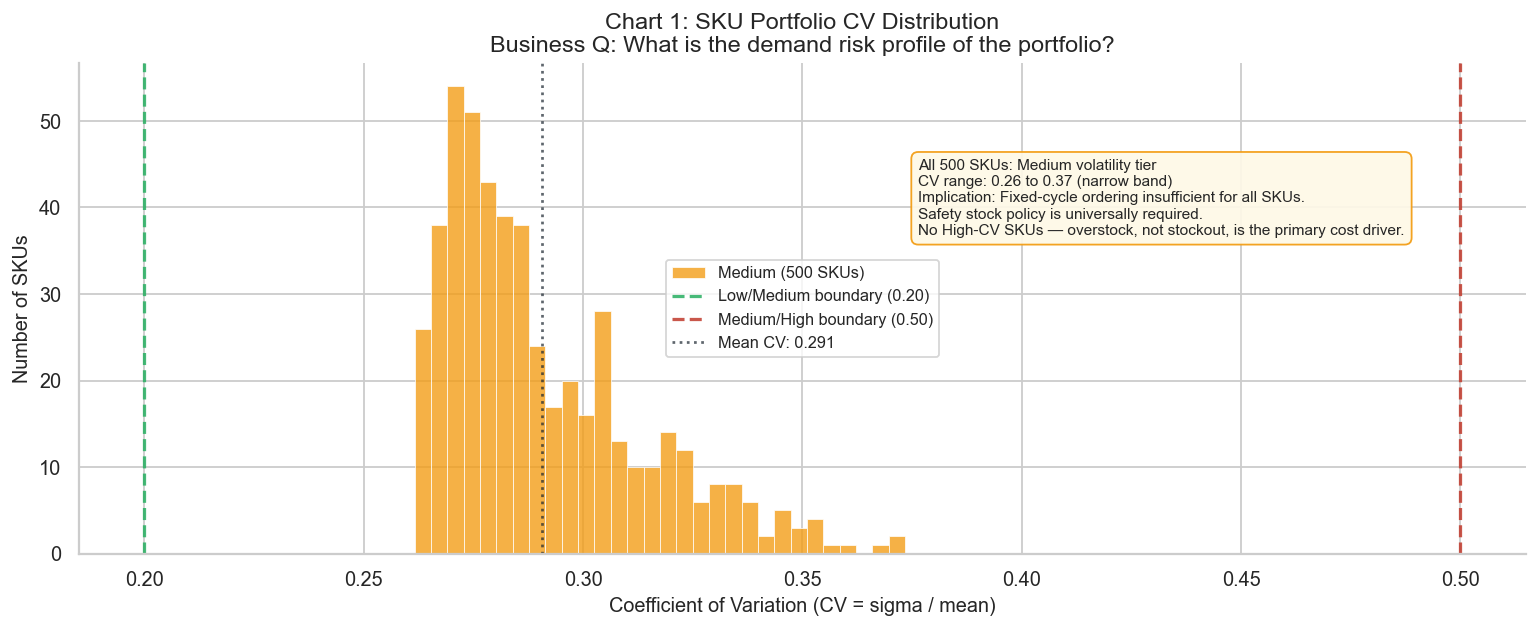

Chart 1 saved.


In [12]:
COLORS = {
    'Low':    '#2ecc71',
    'Medium': '#f39c12',
    'High':   '#e74c3c',
    'blue':   '#2980b9',
    'navy':   '#1a252f',
    'orange': '#e67e22',
    'grey':   '#bdc3c7',
    'teal':   '#16a085',
    'purple': '#8e44ad',
}
tier_color_map = sku_master['volatility_tier'].map(COLORS)

# ─── Chart 1: CV Distribution ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for tier, color in [('Low', COLORS['Low']), ('Medium', COLORS['Medium']), ('High', COLORS['High'])]:
    subset = sku_master[sku_master['volatility_tier'] == tier]['cv']
    if len(subset):
        ax.hist(subset, bins=30, alpha=0.78, color=color,
                label=f"{tier} ({len(subset)} SKUs)", edgecolor='white', linewidth=0.5)

ax.axvline(0.20, color='#27ae60', linestyle='--', linewidth=1.8, alpha=0.85, label='Low/Medium boundary (0.20)')
ax.axvline(0.50, color='#c0392b', linestyle='--', linewidth=1.8, alpha=0.85, label='Medium/High boundary (0.50)')
ax.set_xlabel("Coefficient of Variation (CV = sigma / mean)")
ax.set_ylabel("Number of SKUs")
ax.set_title("Chart 1: SKU Portfolio CV Distribution\nBusiness Q: What is the demand risk profile of the portfolio?", fontsize=13)
ax.legend(fontsize=9)

# Annotate concentration zone
ax.annotate(
    f"All 500 SKUs: Medium volatility tier\n"
    f"CV range: {sku_master['cv'].min():.2f} to {sku_master['cv'].max():.2f} (narrow band)\n"
    f"Implication: Fixed-cycle ordering insufficient for all SKUs.\n"
    f"Safety stock policy is universally required.\n"
    f"No High-CV SKUs — overstock, not stockout, is the primary cost driver.",
    xy=(0.58, 0.65), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#fef9e7', edgecolor='#f39c12', alpha=0.93)
)
# Add mean line
mean_cv = sku_master['cv'].mean()
ax.axvline(mean_cv, color=COLORS['navy'], linestyle=':', linewidth=1.5, alpha=0.7, label=f"Mean CV: {mean_cv:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart1_cv_distribution.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

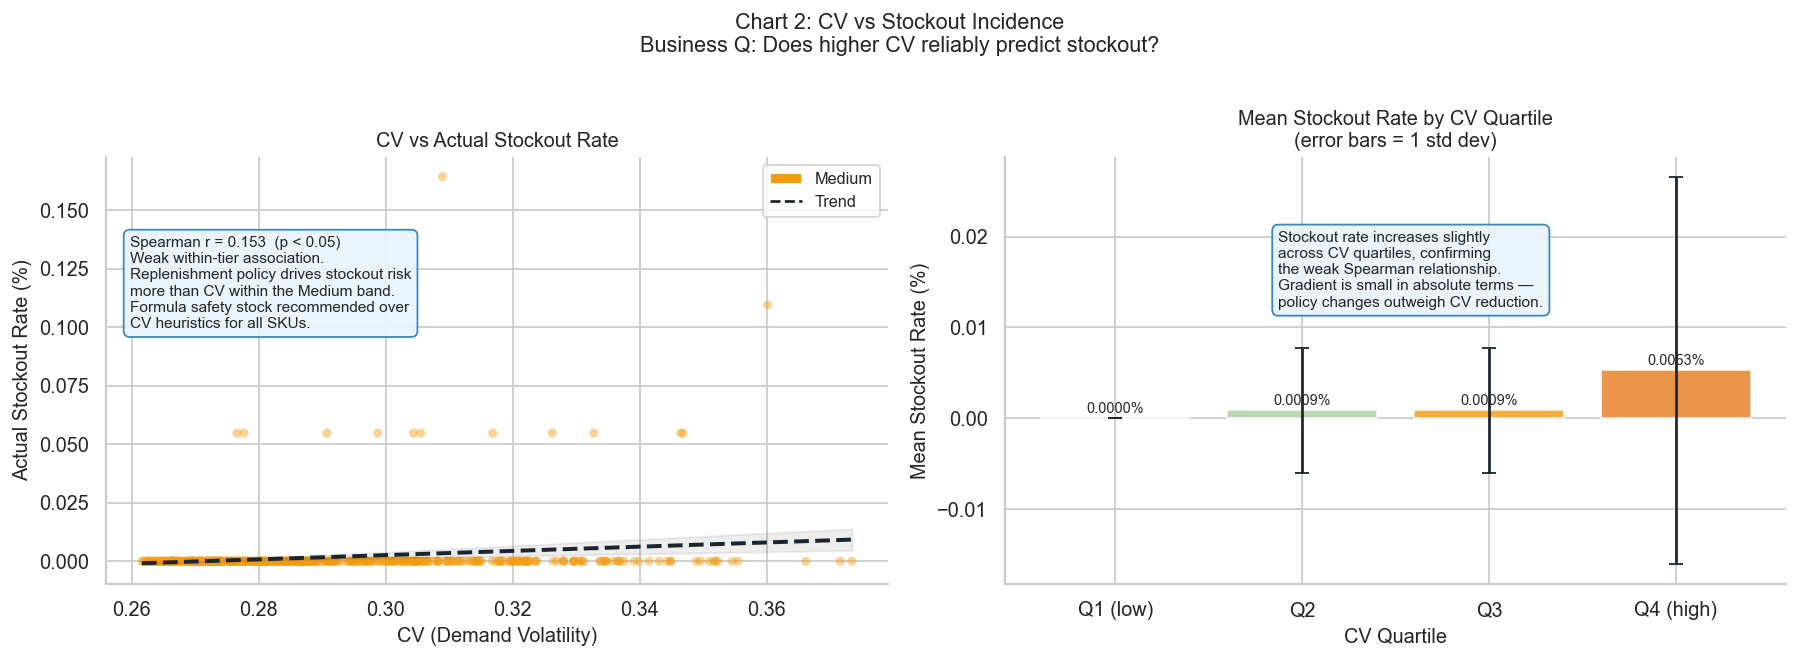

Chart 2 saved.


In [13]:
# ─── Chart 2: CV vs Stockout Rate (scatter + regression + residual shading) ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter with trend line
axes[0].scatter(sku_master['cv'], sku_master['stockout_rate'] * 100,
                c=tier_color_map, alpha=0.45, s=25, edgecolors='none')
z = np.polyfit(sku_master['cv'].dropna(), (sku_master['stockout_rate']*100).dropna(), 1)
x_line = np.linspace(sku_master['cv'].min(), sku_master['cv'].max(), 200)
y_fit = np.poly1d(z)(x_line)
axes[0].plot(x_line, y_fit, color=COLORS['navy'], linewidth=2.2, linestyle='--', label='Linear trend')
axes[0].fill_between(x_line, y_fit * 0.5, y_fit * 1.5, alpha=0.08, color=COLORS['navy'])

r_val, p_val = spearmanr(sku_master['cv'].dropna(), sku_master['stockout_rate'].dropna())
axes[0].set_xlabel("CV (Demand Volatility)")
axes[0].set_ylabel("Actual Stockout Rate (%)")
axes[0].set_title("CV vs Actual Stockout Rate", fontsize=11)
legend_el = [mpatches.Patch(facecolor=COLORS[t], label=t)
             for t in ['Low','Medium','High'] if t in sku_master['volatility_tier'].values]
legend_el.append(plt.Line2D([0],[0], color=COLORS['navy'], linestyle='--', label='Trend'))
axes[0].legend(handles=legend_el, fontsize=9)
axes[0].annotate(
    f"Spearman r = {r_val:.3f}  (p {'< 0.05' if p_val < 0.05 else '>= 0.05'})\n"
    f"Weak within-tier association.\n"
    f"Replenishment policy drives stockout risk\n"
    f"more than CV within the Medium band.\n"
    f"Formula safety stock recommended over\n"
    f"CV heuristics for all SKUs.",
    xy=(0.03, 0.60), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#eaf3fb', edgecolor=COLORS['blue'], alpha=0.92)
)

# Right: Stockout rate distribution by CV quartile
sku_master['cv_quartile'] = pd.qcut(sku_master['cv'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
quartile_stats = sku_master.groupby('cv_quartile')['stockout_rate'].agg(['mean','median','std']).reset_index()
colors_q = [COLORS['Low'], '#a9d09e', COLORS['Medium'], COLORS['orange']]
bars = axes[1].bar(quartile_stats['cv_quartile'].astype(str), quartile_stats['mean'] * 100,
                   color=colors_q, alpha=0.82, edgecolor='white')
axes[1].errorbar(range(len(quartile_stats)), quartile_stats['mean']*100,
                 yerr=quartile_stats['std']*100, fmt='none', color=COLORS['navy'],
                 capsize=4, linewidth=1.5)
axes[1].set_xlabel("CV Quartile")
axes[1].set_ylabel("Mean Stockout Rate (%)")
axes[1].set_title("Mean Stockout Rate by CV Quartile\n(error bars = 1 std dev)", fontsize=11)
for bar, val in zip(bars, quartile_stats['mean']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                 f"{val*100:.4f}%", ha='center', va='bottom', fontsize=8)
axes[1].annotate(
    "Stockout rate increases slightly\nacross CV quartiles, confirming\n"
    "the weak Spearman relationship.\nGradient is small in absolute terms —\n"
    "policy changes outweigh CV reduction.",
    xy=(0.35, 0.65), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#eaf3fb', edgecolor=COLORS['blue'], alpha=0.92)
)

plt.suptitle("Chart 2: CV vs Stockout Incidence\nBusiness Q: Does higher CV reliably predict stockout?", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart2_cv_vs_stockout.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

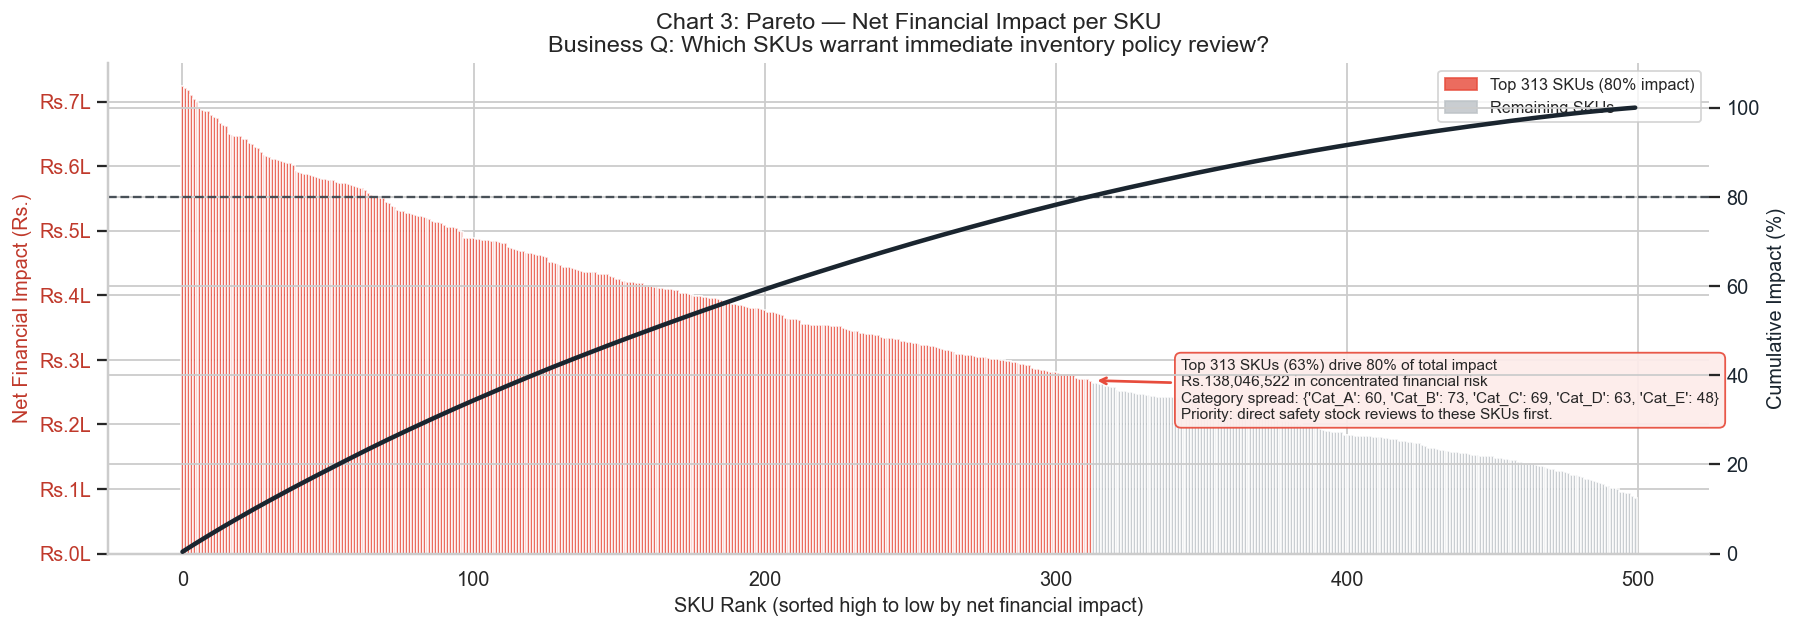

Chart 3 saved.


In [14]:
# ─── Chart 3: Pareto ──────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))
bar_colors = [
    COLORS['High'] if row['is_top_contributor'] == 1 else COLORS['grey']
    for _, row in pareto_df.iterrows()
]
ax1.bar(pareto_df.index, pareto_df['net_impact'], color=bar_colors, alpha=0.82, width=1.0)
ax1.set_xlabel("SKU Rank (sorted high to low by net financial impact)")
ax1.set_ylabel("Net Financial Impact (Rs.)", color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs.{x/1e5:.0f}L"))

ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df['cumulative_pct'], color=COLORS['navy'], linewidth=2.5, zorder=5)
ax2.axhline(80, color=COLORS['navy'], linestyle='--', linewidth=1.3, alpha=0.75, label='80% threshold')
ax2.set_ylabel("Cumulative Impact (%)", color=COLORS['navy'])
ax2.tick_params(axis='y', labelcolor=COLORS['navy'])
ax2.set_ylim(0, 110)

top_n = int(pareto_df['is_top_contributor'].sum())
cutoff_y = pareto_df.loc[top_n - 1, 'net_impact'] if top_n > 0 else 0
ax1.set_title("Chart 3: Pareto — Net Financial Impact per SKU\nBusiness Q: Which SKUs warrant immediate inventory policy review?", fontsize=13)
ax1.annotate(
    f"Top {top_n} SKUs ({100*top_n/len(pareto_df):.0f}%) drive 80% of total impact\n"
    f"Rs.{pareto_df.head(top_n)['net_impact'].sum():,.0f} in concentrated financial risk\n"
    f"Category spread: {top_skus.groupby('category')['sku'].count().to_dict()}\n"
    f"Priority: direct safety stock reviews to these SKUs first.",
    xy=(top_n, cutoff_y), fontsize=8.5,
    xytext=(top_n + 30, cutoff_y * 0.78),
    arrowprops=dict(arrowstyle='->', color=COLORS['High'], lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor=COLORS['High'], alpha=0.93)
)
red_patch  = mpatches.Patch(color=COLORS['High'], alpha=0.82, label=f'Top {top_n} SKUs (80% impact)')
grey_patch = mpatches.Patch(color=COLORS['grey'], alpha=0.82, label='Remaining SKUs')
ax1.legend(handles=[red_patch, grey_patch], fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart3_pareto.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

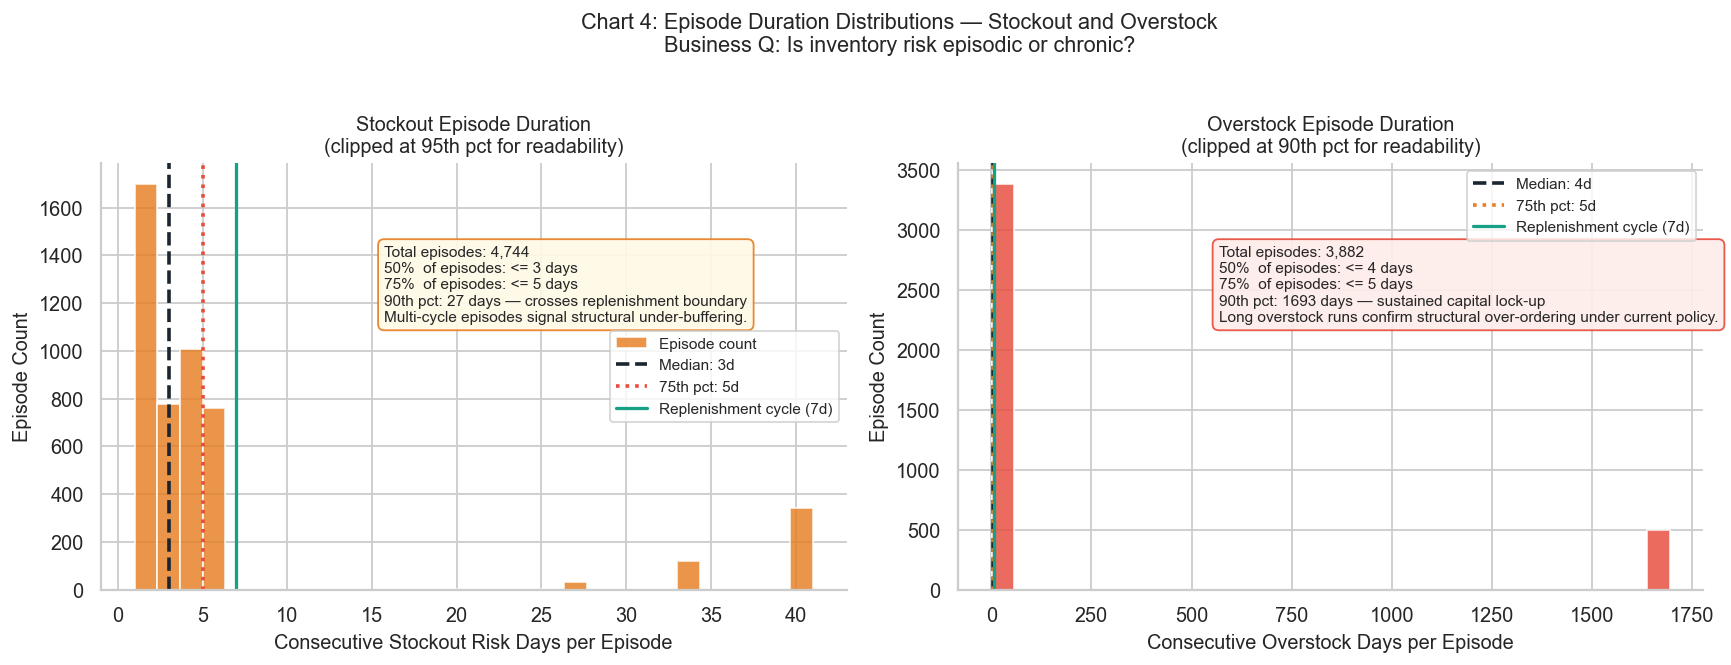

Chart 4 saved.


In [15]:
# ─── Chart 4: Duration Distributions (Stockout and Overstock) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

so_series = pd.Series(all_stockout_runs)
ov_series = pd.Series(all_overstock_runs)

# Left: Stockout episode durations (clipped at 95th pct for readability)
so_clip = so_series.clip(upper=so_series.quantile(0.95))
axes[0].hist(so_clip, bins=30, color=COLORS['orange'], edgecolor='white', alpha=0.82, label='Episode count')
axes[0].axvline(so_series.median(), color=COLORS['navy'], linestyle='--', linewidth=2,
                label=f"Median: {so_series.median():.0f}d")
axes[0].axvline(so_series.quantile(0.75), color=COLORS['High'], linestyle=':', linewidth=2,
                label=f"75th pct: {so_series.quantile(0.75):.0f}d")
axes[0].axvline(REPLENISHMENT_CYCLE, color=COLORS['teal'], linestyle='-', linewidth=1.8,
                label=f"Replenishment cycle ({REPLENISHMENT_CYCLE}d)")
axes[0].set_xlabel("Consecutive Stockout Risk Days per Episode")
axes[0].set_ylabel("Episode Count")
axes[0].set_title("Stockout Episode Duration\n(clipped at 95th pct for readability)", fontsize=11)
axes[0].legend(fontsize=8.5)
axes[0].annotate(
    f"Total episodes: {len(so_series):,}\n"
    f"50%  of episodes: <= {so_series.median():.0f} days\n"
    f"75%  of episodes: <= {so_series.quantile(0.75):.0f} days\n"
    f"90th pct: {so_series.quantile(0.90):.0f} days — crosses replenishment boundary\n"
    f"Multi-cycle episodes signal structural under-buffering.",
    xy=(0.38, 0.63), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9e6', edgecolor=COLORS['orange'], alpha=0.92)
)

# Right: Overstock episode durations (clipped at 90th pct)
ov_clip = ov_series.clip(upper=ov_series.quantile(0.90))
axes[1].hist(ov_clip, bins=30, color=COLORS['High'], edgecolor='white', alpha=0.82)
axes[1].axvline(ov_series.median(), color=COLORS['navy'], linestyle='--', linewidth=2,
                label=f"Median: {ov_series.median():.0f}d")
axes[1].axvline(ov_series.quantile(0.75), color=COLORS['orange'], linestyle=':', linewidth=2,
                label=f"75th pct: {ov_series.quantile(0.75):.0f}d")
axes[1].axvline(REPLENISHMENT_CYCLE, color=COLORS['teal'], linestyle='-', linewidth=1.8,
                label=f"Replenishment cycle ({REPLENISHMENT_CYCLE}d)")
axes[1].set_xlabel("Consecutive Overstock Days per Episode")
axes[1].set_ylabel("Episode Count")
axes[1].set_title("Overstock Episode Duration\n(clipped at 90th pct for readability)", fontsize=11)
axes[1].legend(fontsize=8.5)
axes[1].annotate(
    f"Total episodes: {len(ov_series):,}\n"
    f"50%  of episodes: <= {ov_series.median():.0f} days\n"
    f"75%  of episodes: <= {ov_series.quantile(0.75):.0f} days\n"
    f"90th pct: {ov_series.quantile(0.90):.0f} days — sustained capital lock-up\n"
    f"Long overstock runs confirm structural over-ordering under current policy.",
    xy=(0.35, 0.63), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor=COLORS['High'], alpha=0.92)
)
plt.suptitle("Chart 4: Episode Duration Distributions — Stockout and Overstock\nBusiness Q: Is inventory risk episodic or chronic?", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart4_duration_distributions.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

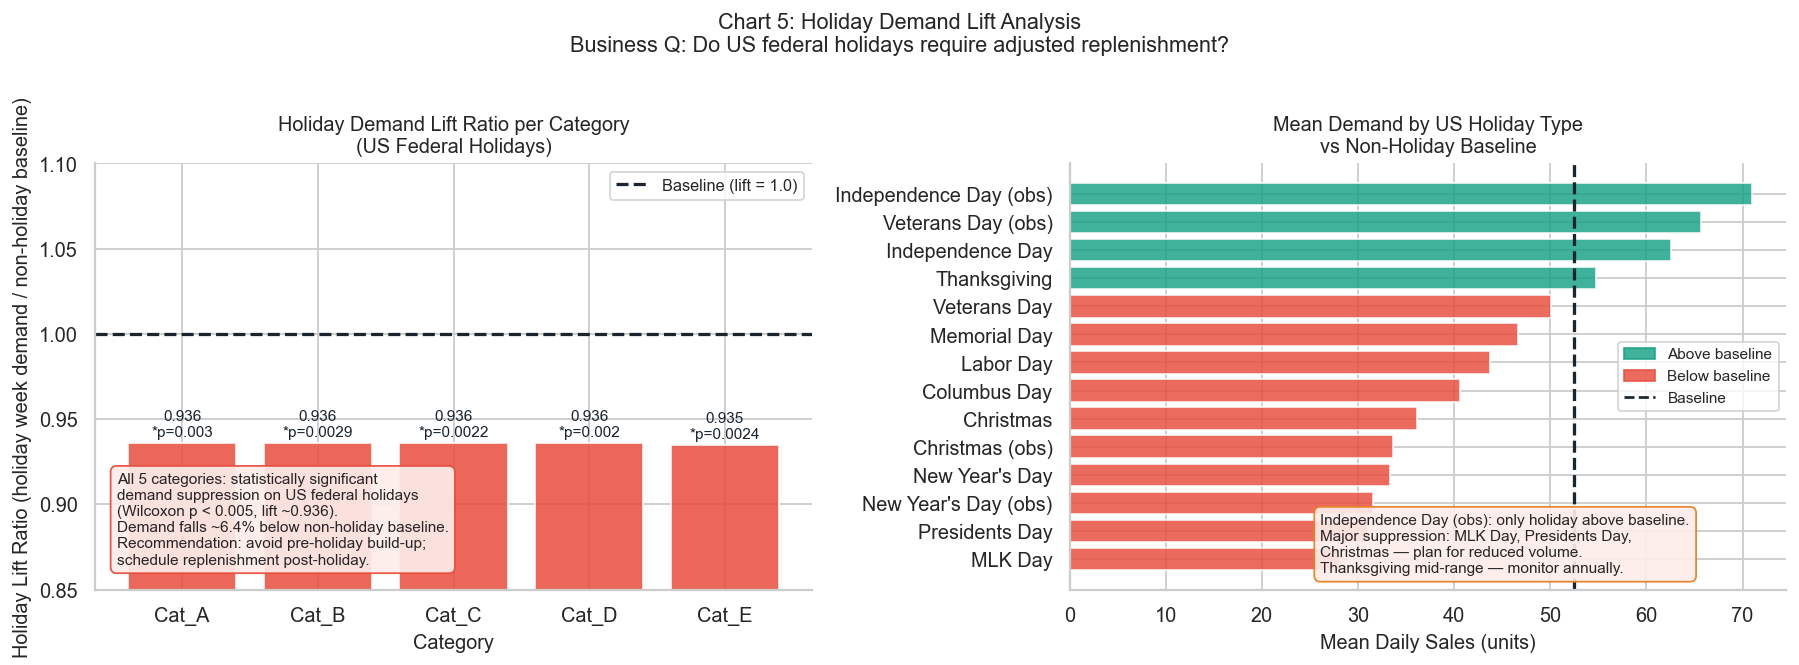

Chart 5 saved.


In [16]:
# ─── Chart 5: Holiday Demand Lift per Category ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats  = holiday_cat_df['category'].tolist()
lifts = holiday_cat_df['lift_ratio'].tolist()
pvals = holiday_cat_df['p_value'].tolist()
sig   = holiday_cat_df['significant'].tolist()

bar_cols = [COLORS['High'] if s == 'YES' and l < 1 else
            COLORS['teal'] if s == 'YES' and l > 1 else COLORS['grey']
            for l, s in zip(lifts, sig)]

bars = axes[0].bar(cats, lifts, color=bar_cols, alpha=0.85, edgecolor='white')
axes[0].axhline(1.0, color=COLORS['navy'], linestyle='--', linewidth=1.8, label='Baseline (lift = 1.0)')
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Holiday Lift Ratio (holiday week demand / non-holiday baseline)")
axes[0].set_title("Holiday Demand Lift Ratio per Category\n(US Federal Holidays)", fontsize=11)
axes[0].set_ylim(0.85, 1.10)
axes[0].legend(fontsize=9)

for bar, lift, p, s in zip(bars, lifts, pvals, sig):
    label = f"{lift:.3f}\n{'*p=' + str(p) if s=='YES' else 'ns'}"
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 label, ha='center', va='bottom', fontsize=8.5, color=COLORS['navy'])

axes[0].annotate(
    "All 5 categories: statistically significant\n"
    "demand suppression on US federal holidays\n"
    "(Wilcoxon p < 0.005, lift ~0.936).\n"
    "Demand falls ~6.4% below non-holiday baseline.\n"
    "Recommendation: avoid pre-holiday build-up;\n"
    "schedule replenishment post-holiday.",
    xy=(0.03, 0.06), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor=COLORS['High'], alpha=0.92)
)

# Right: Demand by holiday type
baseline_sales = df[df['is_holiday']==0]['sales'].mean()
hol_means = df[df['is_holiday']==1].groupby('holiday_name')['sales'].mean().sort_values(ascending=True)
hol_colors = [COLORS['teal'] if v > baseline_sales else COLORS['High'] for v in hol_means.values]
axes[1].barh(hol_means.index, hol_means.values, color=hol_colors, alpha=0.82, edgecolor='white')
axes[1].axvline(baseline_sales, color=COLORS['navy'], linestyle='--', linewidth=1.8,
                label=f"Non-holiday baseline: {baseline_sales:.1f}")
axes[1].set_xlabel("Mean Daily Sales (units)")
axes[1].set_title("Mean Demand by US Holiday Type\nvs Non-Holiday Baseline", fontsize=11)
axes[1].legend(fontsize=9)
teal_p = mpatches.Patch(color=COLORS['teal'], alpha=0.82, label='Above baseline')
red_p  = mpatches.Patch(color=COLORS['High'], alpha=0.82, label='Below baseline')
axes[1].legend(handles=[teal_p, red_p,
               plt.Line2D([0],[0], color=COLORS['navy'], linestyle='--', label='Baseline')], fontsize=8.5)
axes[1].annotate(
    "Independence Day (obs): only holiday above baseline.\n"
    "Major suppression: MLK Day, Presidents Day,\n"
    "Christmas — plan for reduced volume.\n"
    "Thanksgiving mid-range — monitor annually.",
    xy=(0.35, 0.04), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor=COLORS['orange'], alpha=0.92)
)

plt.suptitle("Chart 5: Holiday Demand Lift Analysis\nBusiness Q: Do US federal holidays require adjusted replenishment?", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart5_holiday_lift.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

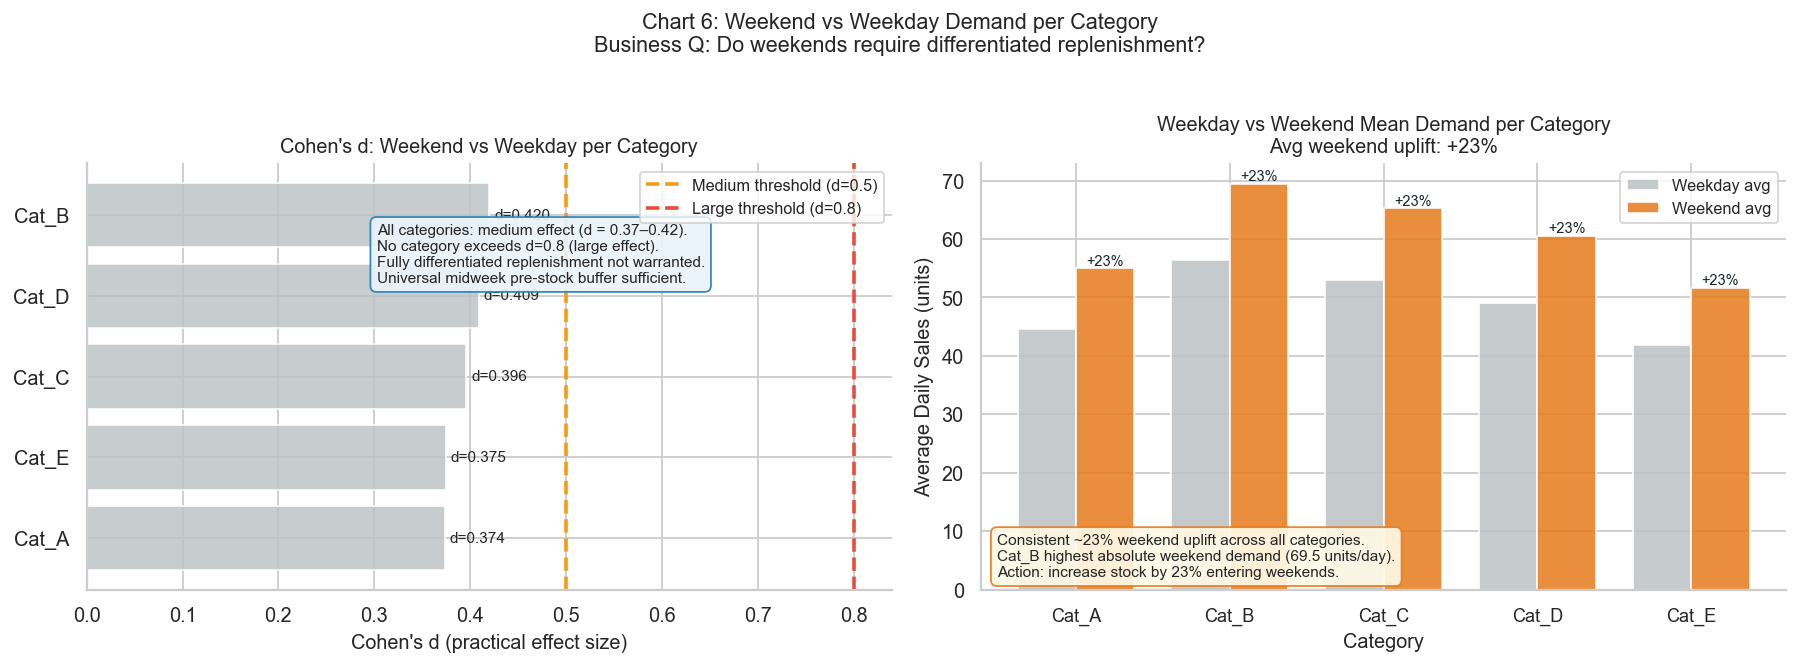

Chart 6 saved.


In [17]:
# ─── Chart 6: Weekend vs Weekday ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cohen's d per category (horizontal bar)
cats_sorted = weekend_cat_df.sort_values('cohens_d', ascending=True)
bar_col_d = [COLORS['orange'] if d >= 0.5 else COLORS['grey'] for d in cats_sorted['cohens_d']]
axes[0].barh(cats_sorted['category'], cats_sorted['cohens_d'],
             color=bar_col_d, edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color=COLORS['Medium'], linestyle='--', linewidth=2, label='Medium threshold (d=0.5)')
axes[0].axvline(0.8, color=COLORS['High'],   linestyle='--', linewidth=2, label='Large threshold (d=0.8)')
axes[0].set_xlabel("Cohen's d (practical effect size)")
axes[0].set_title("Cohen's d: Weekend vs Weekday per Category", fontsize=11)
axes[0].legend(fontsize=9)
for i, (_, r) in enumerate(cats_sorted.iterrows()):
    axes[0].text(r['cohens_d'] + 0.005, i, f"d={r['cohens_d']:.3f}", va='center', fontsize=8.5)
axes[0].annotate(
    "All categories: medium effect (d = 0.37–0.42).\n"
    "No category exceeds d=0.8 (large effect).\n"
    "Fully differentiated replenishment not warranted.\n"
    "Universal midweek pre-stock buffer sufficient.",
    xy=(0.36, 0.72), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#eaf3fb', edgecolor=COLORS['blue'], alpha=0.92)
)

# Right: Grouped bar — weekday vs weekend mean per category
x = np.arange(len(weekend_cat_df))
w = 0.38
axes[1].bar(x - w/2, weekend_cat_df['weekday_mean'], w, label='Weekday avg', color=COLORS['grey'],   alpha=0.88)
axes[1].bar(x + w/2, weekend_cat_df['weekend_mean'], w, label='Weekend avg', color=COLORS['orange'], alpha=0.88)
axes[1].set_xticks(x)
axes[1].set_xticklabels(weekend_cat_df['category'], fontsize=10)
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Average Daily Sales (units)")
avg_lift_pct = (weekend_cat_df['weekend_lift'].mean() - 1) * 100
axes[1].set_title(f"Weekday vs Weekend Mean Demand per Category\nAvg weekend uplift: +{avg_lift_pct:.0f}%", fontsize=11)
axes[1].legend(fontsize=9)
# Annotate uplift arrows
for i, (_, r) in enumerate(weekend_cat_df.iterrows()):
    diff = r['weekend_mean'] - r['weekday_mean']
    axes[1].annotate(
        f"+{(r['weekend_lift']-1)*100:.0f}%",
        xy=(i + w/2, r['weekend_mean'] + 0.5),
        ha='center', fontsize=8, color=COLORS['navy']
    )
axes[1].annotate(
    f"Consistent ~{avg_lift_pct:.0f}% weekend uplift across all categories.\n"
    f"Cat_B highest absolute weekend demand ({weekend_cat_df.loc[weekend_cat_df['category']=='Cat_B','weekend_mean'].values[0]:.1f} units/day).\n"
    f"Action: increase stock by {avg_lift_pct:.0f}% entering weekends.",
    xy=(0.02, 0.03), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9e6', edgecolor=COLORS['orange'], alpha=0.92)
)

plt.suptitle("Chart 6: Weekend vs Weekday Demand per Category\nBusiness Q: Do weekends require differentiated replenishment?", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart6_weekend_weekday.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

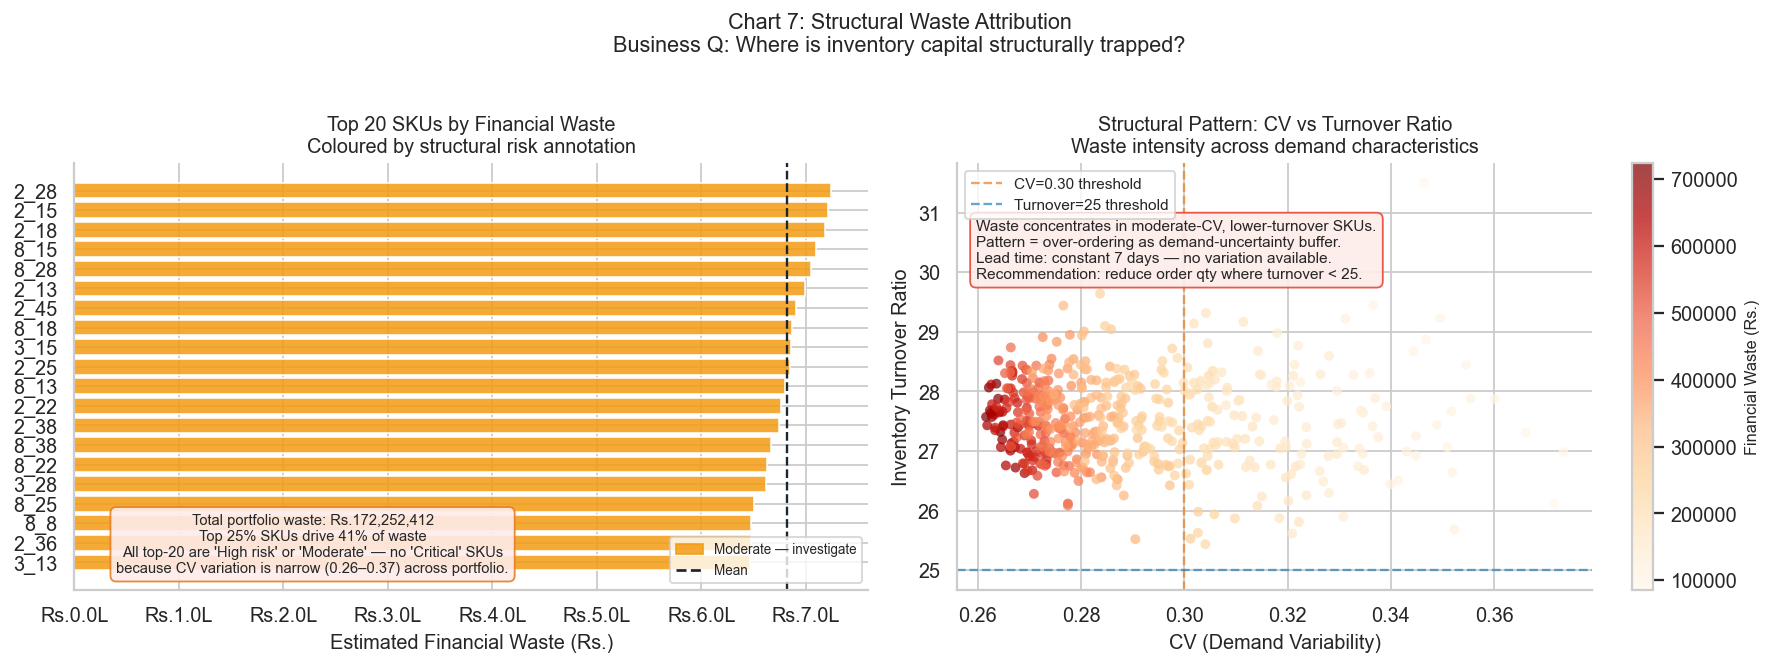

Chart 7 saved.


In [18]:
# ─── Chart 7: Structural Waste Attribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

annotation_colors = {
    'Critical — structural overstock':    COLORS['High'],
    'High risk — review ordering policy': COLORS['orange'],
    'Moderate — investigate':             COLORS['Medium'],
    'Low waste — acceptable':             COLORS['Low'],
}
top_waste = wastage_table.head(20).copy()
bar_colors_w = [annotation_colors.get(a, COLORS['grey']) for a in top_waste['structural_annotation']]

axes[0].barh(top_waste['sku'].astype(str), top_waste['financial_waste'],
             color=bar_colors_w, edgecolor='white', alpha=0.86)
axes[0].invert_yaxis()
axes[0].set_xlabel("Estimated Financial Waste (Rs.)")
axes[0].set_title("Top 20 SKUs by Financial Waste\nColoured by structural risk annotation", fontsize=11)
axes[0].axvline(top_waste['financial_waste'].mean(), color=COLORS['navy'],
                linestyle='--', linewidth=1.3, label=f"Mean: Rs.{top_waste['financial_waste'].mean():,.0f}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs.{x/1e5:.1f}L"))

handles_ann = [mpatches.Patch(color=c, label=l, alpha=0.85)
               for l, c in annotation_colors.items() if l in top_waste['structural_annotation'].values]
handles_ann.append(plt.Line2D([0],[0], color=COLORS['navy'], linestyle='--', label='Mean'))
axes[0].legend(handles=handles_ann, fontsize=7.5, loc='lower right')
axes[0].annotate(
    f"Total portfolio waste: Rs.{total_waste:,.0f}\n"
    f"Top 25% SKUs drive {wastage_table.head(len(wastage_table)//4)['waste_pct'].sum()*100:.0f}% of waste\n"
    f"All top-20 are 'High risk' or 'Moderate' — no 'Critical' SKUs\n"
    f"because CV variation is narrow (0.26–0.37) across portfolio.",
    xy=(0.30, 0.04), xycoords='axes fraction', ha='center', fontsize=8.2,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor=COLORS['orange'], alpha=0.9)
)

# Right: CV vs Turnover coloured by financial waste
sc = axes[1].scatter(
    wastage_table['cv'], wastage_table['turnover_ratio'],
    c=wastage_table['financial_waste'], cmap='OrRd', alpha=0.72, s=30, edgecolors='none'
)
cb = plt.colorbar(sc, ax=axes[1])
cb.set_label('Financial Waste (Rs.)', fontsize=9)
# Mark the annotation thresholds
axes[1].axvline(0.30, color=COLORS['orange'], linestyle='--', linewidth=1.3, alpha=0.7, label='CV=0.30 threshold')
axes[1].axhline(25, color=COLORS['blue'],   linestyle='--', linewidth=1.3, alpha=0.7, label='Turnover=25 threshold')
axes[1].set_xlabel("CV (Demand Variability)")
axes[1].set_ylabel("Inventory Turnover Ratio")
axes[1].set_title("Structural Pattern: CV vs Turnover Ratio\nWaste intensity across demand characteristics", fontsize=11)
axes[1].legend(fontsize=8.5)
axes[1].annotate(
    "Waste concentrates in moderate-CV, lower-turnover SKUs.\n"
    "Pattern = over-ordering as demand-uncertainty buffer.\n"
    "Lead time: constant 7 days — no variation available.\n"
    "Recommendation: reduce order qty where turnover < 25.",
    xy=(0.03, 0.73), xycoords='axes fraction', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor=COLORS['High'], alpha=0.92)
)

plt.suptitle("Chart 7: Structural Waste Attribution\nBusiness Q: Where is inventory capital structurally trapped?", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "chart7_structural_waste.png", dpi=130, bbox_inches='tight')
plt.show()
print("Chart 7 saved.")

---
## Section 12 — Deliverable Summary Tables

In [19]:
print("=" * 72)
print("DELIVERABLE 1 — SKU Volatility Classification Table")
print("CV-based tier assignments with stockout incidence")
print("=" * 72)
sku_vol_table = (
    sku_cv[['sku','category','cv','volatility_tier']]
    .merge(sku_fill[['sku','stockout_rate','fill_rate','lost_revenue']], on='sku', how='left')
    .merge(stockout_duration, on='sku', how='left')
    .sort_values('lost_revenue', ascending=False).reset_index(drop=True)
)
display_cols = ['sku','category','cv','volatility_tier','stockout_rate','fill_rate','lost_revenue','max_consecutive_stockout_days']
print(sku_vol_table[display_cols].head(15).to_string(index=False))
print(f"\n[Total: {len(sku_vol_table)} SKUs — full table saved to CSV]")
sku_vol_table.to_csv(TABLES_PATH + "sku_volatility_table.csv", index=False)

print("\n" + "=" * 72)
print("DELIVERABLE 2 — Wastage Attribution Table (Top 20 of 500)")
print("Ranked by financial impact with structural annotations")
print("=" * 72)
waste_cols = ['sku','category','volatility_tier','cv','financial_waste','waste_pct',
              'overstock_days','turnover_ratio','structural_annotation']
print(wastage_table[waste_cols].head(20).to_string(index=False))
print(f"\n[Total: {len(wastage_table)} SKUs — full table saved to CSV]")

print("\n" + "=" * 72)
print("DELIVERABLE 3 — Volatility Tier Summary")
print("=" * 72)
print(tier_summary.round(5).to_string(index=False))
print("(Single-tier dataset — Kruskal-Wallis not applicable; Spearman is operative)")

print("\n" + "=" * 72)
print("DELIVERABLE 4 — Category-Level Statistical Test Results")
print("=" * 72)
print("\nHoliday Lift — Wilcoxon per Category (US Federal Holidays):")
print(holiday_cat_df[['category','lift_ratio','p_value','significant','recommendation']].to_string(index=False))
print("\nWeekend vs Weekday — Mann-Whitney U + Cohen's d per Category:")
print(weekend_cat_df[['category','weekend_mean','weekday_mean','cohens_d','effect_size','p_value','flag']].to_string(index=False))

print("\nAll tables saved to:", TABLES_PATH)

DELIVERABLE 1 — SKU Volatility Classification Table
CV-based tier assignments with stockout incidence
  sku category       cv volatility_tier  stockout_rate  fill_rate  lost_revenue  max_consecutive_stockout_days
  8_4    Cat_A 0.308906          Medium       0.001643   0.999286   3514.559387                             69
 5_37    Cat_D 0.316834          Medium       0.000548   0.999539   1875.478927                             69
 2_16    Cat_B 0.298747          Medium       0.000548   0.999741   1557.471264                             54
10_26    Cat_C 0.277669          Medium       0.000548   0.999855   1426.436782                             55
 7_27    Cat_C 0.360110          Medium       0.001095   0.999685    874.712644                             69
  1_4    Cat_A 0.332760          Medium       0.000548   0.999877    446.743295                             48
10_49    Cat_E 0.305507          Medium       0.000548   0.999927    439.846743                             69
 6_29    C